In [ ]:
!pip install matplotlib cartopy ismn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.8/484.8 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.0 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
from ismn.interface import ISMN_Interface
%matplotlib inline

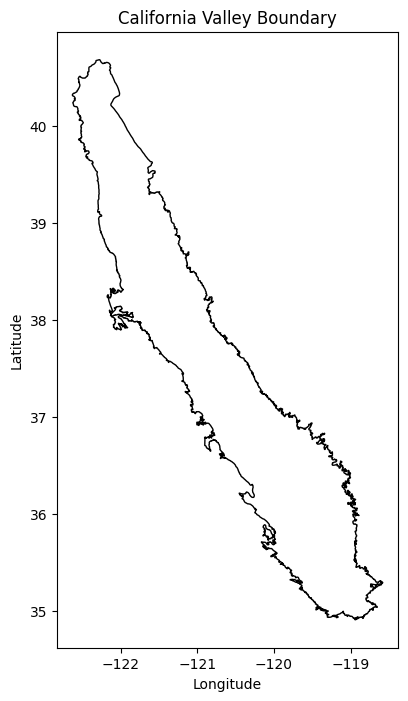

In [ ]:
# Path to shapefile
shp_path = "/content/CV_polygon.kml"

# Read shapefile
cal_valley = gpd.read_file(shp_path)

# Ensure WGS84
cal_valley = cal_valley.to_crs(epsg=4326)

# Plot
fig, ax = plt.subplots(figsize=(6, 8))
cal_valley.plot(ax=ax, edgecolor="black", facecolor="none")
ax.set_title("California Valley Boundary")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


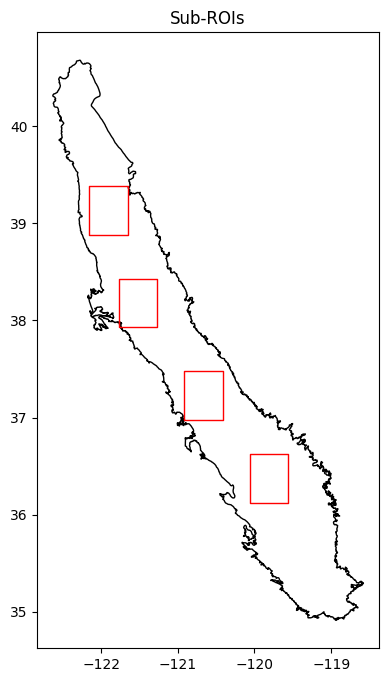

In [ ]:
# Sub-ROI top-left coordinates
top_left_coords = pd.DataFrame({
    "id": [0, 1, 2, 3, 4],
    "lon": [-122.1524, -121.7718, -120.9153, -120.0589, -119.5831],
    "lat": [39.38204, 38.42996, 37.47834, 36.62189, 35.76543]
})

# Define box size (example: 0.5° × 0.5°)
dx = dy = 0.5

subrois = []
for _, r in top_left_coords.iloc[:4].iterrows():
    roi = box(
        r.lon,
        r.lat - dy,
        r.lon + dx,
        r.lat
    )
    subrois.append(roi)

subrois_gdf = gpd.GeoDataFrame(
    geometry=subrois,
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(6, 8))
cal_valley.plot(ax=ax, edgecolor="black", facecolor="none")
subrois_gdf.plot(ax=ax, edgecolor="red", facecolor="none")
plt.title("Sub-ROIs")
plt.show()


In [ ]:
# Path to ISMN data (zip or extracted folder)
data_path = "/content/Data_separate_files_header_20040325_20260113_11126_SmC3_20260209.zip"
ismn_data = ISMN_Interface(data_path, parallel=False)

# Build a GeoDataFrame of ALL stations across all networks
# Coordinates are inside station.metadata, not as direct attributes
records = []
for network in ismn_data.networks:
    for station in ismn_data[network].stations:
        s = ismn_data[network][station]
        meta_dict = s.metadata.to_dict()
        # Extract lat/lon from metadata dict
        # Each entry is a list of (value, depth_from, depth_to) tuples
        lon = meta_dict["longitude"][0][0]
        lat = meta_dict["latitude"][0][0]
        records.append({
            "network": network,
            "station": station,
            "lon": lon,
            "lat": lat
        })

station_df = pd.DataFrame(records)
station_gdf = gpd.GeoDataFrame(
    station_df,
    geometry=gpd.points_from_xy(station_df.lon, station_df.lat),
    crs="EPSG:4326"
)

print(f"Total stations loaded: {len(station_gdf)}")
station_gdf.head()

Using the existing ismn metadata in /content/python_metadata/Data_separate_files_header_20040325_20260113_11126_SmC3_20260209.csv to set up ISMN_Interface. 
If there are issues with the data reader, you can remove the metadata csv file to repeat metadata collection.
Total stations loaded: 46


,network,station,lon,lat,geometry
0,FLUXNET-AMERIFLUX,BouldinIslandAlfalfa,-121.49933,38.09915,POINT (-121.49933 38.09915)
1,FLUXNET-AMERIFLUX,BouldinIslandcorn,-121.53502,38.10902,POINT (-121.53502 38.10902)
2,FLUXNET-AMERIFLUX,ShermanBarn,-121.72715,38.04000,POINT (-121.72715 38.04)
3,FLUXNET-AMERIFLUX,ShermanIsland,-121.75370,38.03730,POINT (-121.7537 38.0373)
4,FLUXNET-AMERIFLUX,TonziRanch,-120.96600,38.43160,POINT (-120.966 38.4316)


Stations inside California Valley: 13


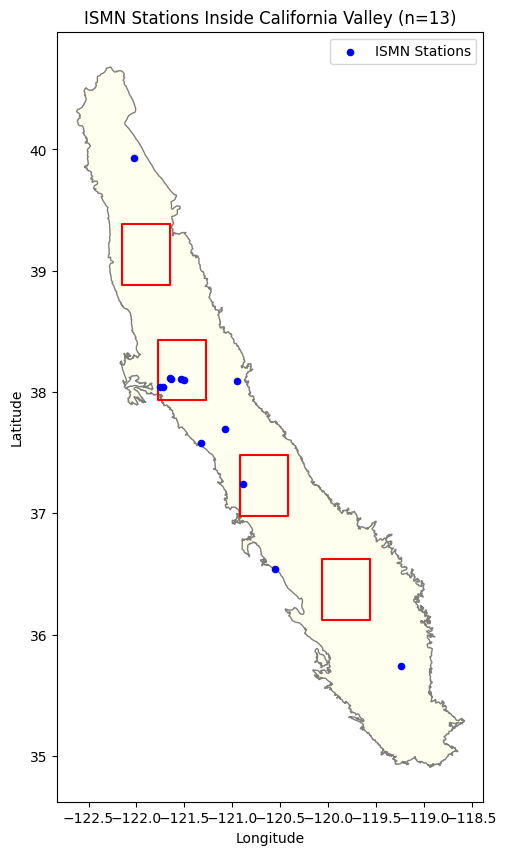

,network,station,lon,lat
0,FLUXNET-AMERIFLUX,BouldinIslandAlfalfa,-121.49933,38.09915
1,FLUXNET-AMERIFLUX,BouldinIslandcorn,-121.53502,38.10902
2,FLUXNET-AMERIFLUX,ShermanBarn,-121.72715,38.04000
3,FLUXNET-AMERIFLUX,ShermanIsland,-121.75370,38.03730
4,FLUXNET-AMERIFLUX,TwitchellAlfalfa,-121.64670,38.11590
5,FLUXNET-AMERIFLUX,TwitchellCorn,-121.64330,38.10470
6,PBO_H2O,ARKANSACRK,-121.32485,37.58189
7,PBO_H2O,CALAVERAS,-120.95124,38.08999
8,PBO_H2O,DELANO-AIR,-119.23665,35.74389
9,PBO_H2O,NOMODESTO,-121.07155,37.69898


In [ ]:
# Spatial join: keep only stations that fall within the California Valley polygon
stations_in_cv = gpd.sjoin(station_gdf, cal_valley, predicate="within", how="inner")

print(f"Stations inside California Valley: {len(stations_in_cv)}")

# Plot
fig, ax = plt.subplots(figsize=(8, 10))
cal_valley.plot(ax=ax, edgecolor="black", facecolor="lightyellow", alpha=0.5)
subrois_gdf.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1.5)
stations_in_cv.plot(ax=ax, color="blue", markersize=20, zorder=5, label="ISMN Stations")
ax.set_title(f"ISMN Stations Inside California Valley (n={len(stations_in_cv)})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()

stations_in_cv[["network", "station", "lon", "lat"]].reset_index(drop=True)

Sub-ROI 0: 0 stations
Sub-ROI 1: 6 stations
FLUXNET-AMERIFLUX/BouldinIslandAlfalfa/CS655_soil_moisture_0.020000_0.020000
FLUXNET-AMERIFLUX/BouldinIslandAlfalfa/ThetaProbe-ML3_soil_moisture_0.200000_0.200000
FLUXNET-AMERIFLUX/BouldinIslandcorn/CS655_soil_moisture_0.020000_0.020000
FLUXNET-AMERIFLUX/BouldinIslandcorn/ThetaProbe-ML3_soil_moisture_0.200000_0.200000
FLUXNET-AMERIFLUX/ShermanBarn/ThetaProbe-ML2X_soil_moisture_0.050000_0.050000
FLUXNET-AMERIFLUX/ShermanIsland/ThetaProbe-ML2X_soil_moisture_0.100000_0.100000
FLUXNET-AMERIFLUX/ShermanIsland/ThetaProbe-ML2X_soil_moisture_0.200000_0.200000
FLUXNET-AMERIFLUX/TwitchellAlfalfa/ThetaProbe-ML2X_soil_moisture_0.100000_0.100000
FLUXNET-AMERIFLUX/TwitchellAlfalfa/ThetaProbe-ML2X_soil_moisture_0.200000_0.200000
FLUXNET-AMERIFLUX/TwitchellCorn/ThetaProbe-ML2X_soil_moisture_0.100000_0.100000
FLUXNET-AMERIFLUX/TwitchellCorn/ThetaProbe-ML2X_soil_moisture_0.200000_0.200000
Sub-ROI 2: 1 stations
FLUXNET-AMERIFLUX/BouldinIslandAlfalfa/CS655_soil_

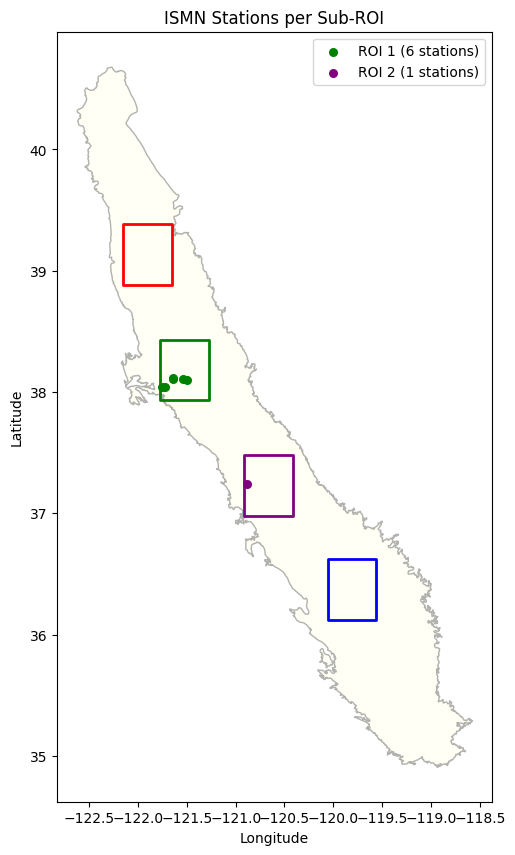

In [ ]:
# Add an 'id' column to subrois_gdf if it doesn't already have one
if "id" not in subrois_gdf.columns:
    subrois_gdf["id"] = range(len(subrois_gdf))

# For each of the first 3 sub-ROIs, find which stations fall inside
subroi_station_dict = {}  # roi_id -> GeoDataFrame of stations

for idx, roi_row in subrois_gdf.iterrows():
    roi_id = roi_row["id"]  # use bracket access, not dot notation
    roi_poly = gpd.GeoDataFrame([roi_row], crs="EPSG:4326")
    matched = gpd.sjoin(station_gdf, roi_poly, predicate="within", how="inner")
    subroi_station_dict[roi_id] = matched
    print(f"Sub-ROI {roi_id}: {len(matched)} stations")
    if len(matched) > 0:
      for _, roi_stations in subroi_station_dict.items():

          has_data = False

          for _, st_row in roi_stations.iterrows():
              nw_name = st_row["network"]
              st_name = st_row["station"]

              try:
                  station_obj = ismn_data[nw_name][st_name]
              except KeyError:
                  continue

              # Iterate over sensors measuring soil_moisture at this station
              for sensor in station_obj.iter_sensors(variable="soil_moisture"):
                  ts = sensor.read_data()
                  sm_col = "soil_moisture"
                  if sm_col in ts.columns and not ts[sm_col].dropna().empty:
                      label = f"{nw_name}/{st_name}/{sensor.name}"
                      print(label)

# Plot all sub-ROI stations together
fig, ax = plt.subplots(figsize=(8, 10))
cal_valley.plot(ax=ax, edgecolor="black", facecolor="lightyellow", alpha=0.3)
colors = {0: "red", 1: "green", 2: "purple", 3:"blue"}

for roi_id, roi_stations in subroi_station_dict.items():
    # Draw the ROI box
    subrois_gdf[subrois_gdf["id"] == roi_id].plot(
        ax=ax, edgecolor=colors[roi_id], facecolor="none", linewidth=2
    )
    if len(roi_stations) > 0:
        roi_stations.plot(
            ax=ax, color=colors[roi_id], markersize=30, zorder=5,
            label=f"ROI {roi_id} ({len(roi_stations)} stations)"
        )

ax.set_title("ISMN Stations per Sub-ROI")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()


--- Sub-ROI 0: No stations found, skipping ---

Sub-ROI 1: 6 station(s)
FLUXNET-AMERIFLUX/BouldinIslandAlfalfa/CS655_soil_moisture_0.020000_0.020000
FLUXNET-AMERIFLUX/BouldinIslandAlfalfa/ThetaProbe-ML3_soil_moisture_0.200000_0.200000
FLUXNET-AMERIFLUX/BouldinIslandcorn/CS655_soil_moisture_0.020000_0.020000
FLUXNET-AMERIFLUX/BouldinIslandcorn/ThetaProbe-ML3_soil_moisture_0.200000_0.200000
FLUXNET-AMERIFLUX/ShermanBarn/ThetaProbe-ML2X_soil_moisture_0.050000_0.050000
FLUXNET-AMERIFLUX/ShermanIsland/ThetaProbe-ML2X_soil_moisture_0.100000_0.100000
FLUXNET-AMERIFLUX/ShermanIsland/ThetaProbe-ML2X_soil_moisture_0.200000_0.200000
FLUXNET-AMERIFLUX/TwitchellAlfalfa/ThetaProbe-ML2X_soil_moisture_0.100000_0.100000
FLUXNET-AMERIFLUX/TwitchellAlfalfa/ThetaProbe-ML2X_soil_moisture_0.200000_0.200000
FLUXNET-AMERIFLUX/TwitchellCorn/ThetaProbe-ML2X_soil_moisture_0.100000_0.100000
FLUXNET-AMERIFLUX/TwitchellCorn/ThetaProbe-ML2X_soil_moisture_0.200000_0.200000


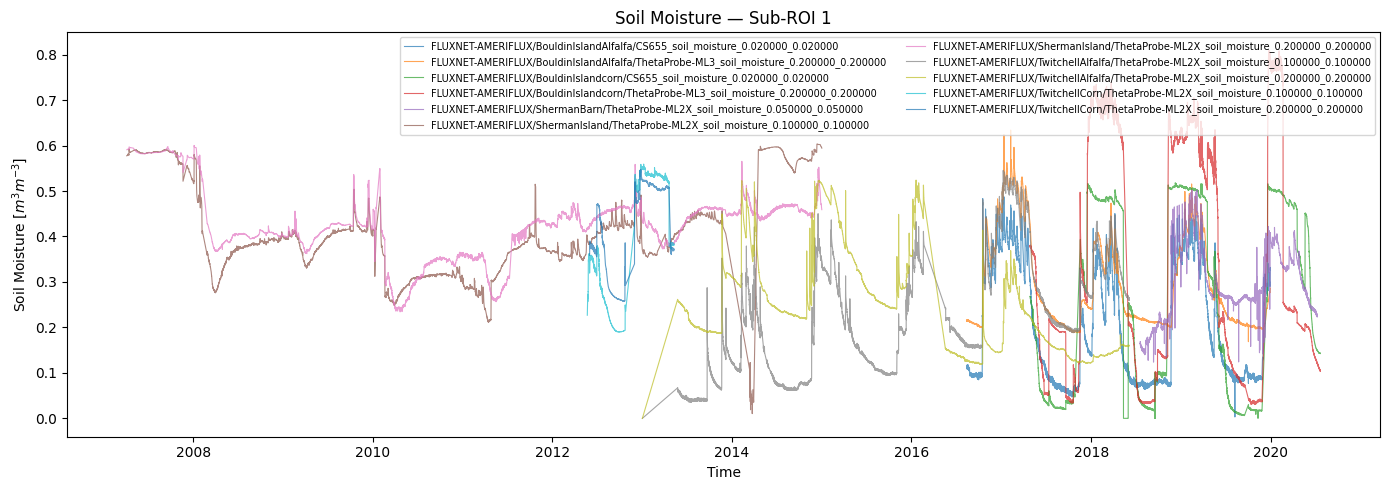


Sub-ROI 2: 1 station(s)
USCRN/Merced-23-WSW/Stevens-Hydraprobe-II-Sdi-12_soil_moisture_0.050000_0.050000
USCRN/Merced-23-WSW/Stevens-Hydraprobe-II-Sdi-12_soil_moisture_0.100000_0.100000
USCRN/Merced-23-WSW/Stevens-Hydraprobe-II-Sdi-12_soil_moisture_0.200000_0.200000
USCRN/Merced-23-WSW/Stevens-Hydraprobe-II-Sdi-12_soil_moisture_0.500000_0.500000
USCRN/Merced-23-WSW/Stevens-Hydraprobe-II-Sdi-12_soil_moisture_1.000000_1.000000


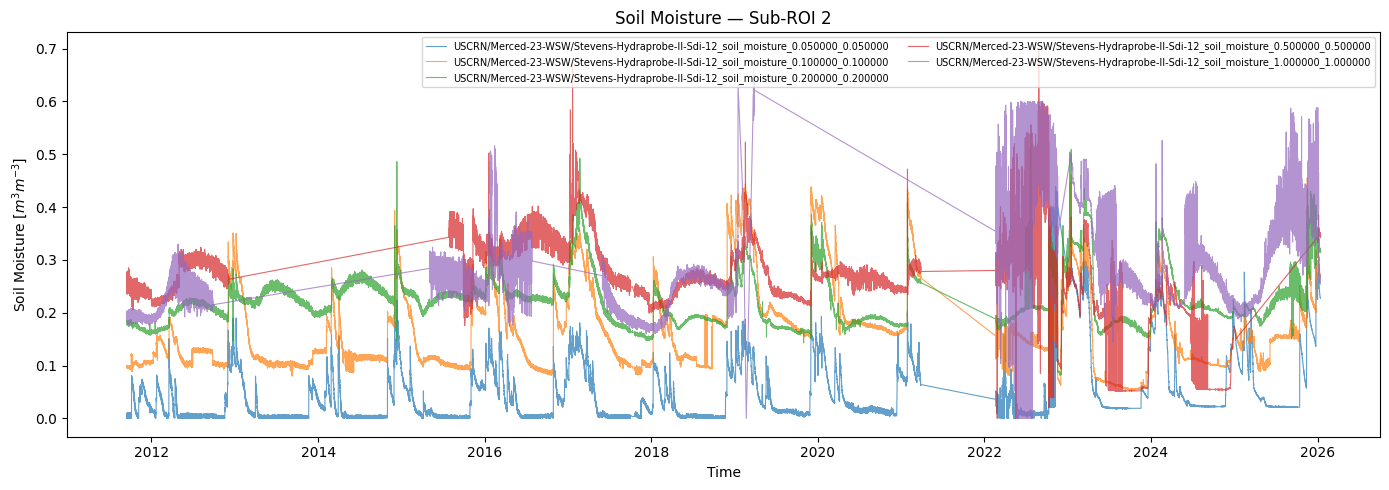


--- Sub-ROI 3: No stations found, skipping ---


In [ ]:
# For each sub-ROI, read soil moisture data from matching stations and plot

for roi_id, roi_stations in subroi_station_dict.items():
    if len(roi_stations) == 0:
        print(f"\n--- Sub-ROI {roi_id}: No stations found, skipping ---")
        continue

    print(f"\n{'='*60}")
    print(f"Sub-ROI {roi_id}: {len(roi_stations)} station(s)")
    print(f"{'='*60}")

    fig, ax = plt.subplots(figsize=(14, 5))
    has_data = False

    for _, st_row in roi_stations.iterrows():
        nw_name = st_row["network"]
        st_name = st_row["station"]

        try:
            station_obj = ismn_data[nw_name][st_name]
        except KeyError:
            continue

        # Iterate over sensors measuring soil_moisture at this station
        for sensor in station_obj.iter_sensors(variable="soil_moisture"):
            ts = sensor.read_data()
            sm_col = "soil_moisture"
            if sm_col in ts.columns and not ts[sm_col].dropna().empty:
                label = f"{nw_name}/{st_name}/{sensor.name}"
                print(label)
                ax.plot(ts.index, ts[sm_col], label=label, alpha=0.7, linewidth=0.8)
                has_data = True

    if has_data:
        ax.set_title(f"Soil Moisture — Sub-ROI {roi_id}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Soil Moisture [$m^3 m^{-3}$]")
        ax.legend(fontsize=7, loc="upper right", ncol=2)
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)
        print(f"  No soil moisture data available for Sub-ROI {roi_id}")

In [ ]:
def plot_sensor_timeseries(ismn_data, sensor_path):
    """
    Plot raw time series for a specific sensor.

    Parameters
    ----------
    ismn_data : ISMN_Interface
        Loaded ISMN interface object.
    sensor_path : str
        Format: "network/station/sensor_name"
        e.g. "FLUXNET-AMERIFLUX/BouldinIslandAlfalfa/CS655_soil_moisture_0.020000_0.020000"
    """
    parts = sensor_path.split("/")
    if len(parts) != 3:
        raise ValueError(
            f"Expected format 'network/station/sensor_name', got: '{sensor_path}'"
        )

    nw_name, st_name, sens_name = parts

    sensor = ismn_data[nw_name][st_name][sens_name]
    ts = sensor.data.copy()

    # Determine the variable column (e.g. 'soil_moisture')
    var_col = [c for c in ts.columns if "_flag" not in c and c != "date_time"]
    if not var_col:
        raise ValueError(f"No data column found for sensor: {sensor_path}")
    var_col = var_col[0]

    # Get metadata for subtitle info
    meta = sensor.metadata.to_dict()
    lat = meta["latitude"][0][0]
    lon = meta["longitude"][0][0]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(ts.index, ts[var_col], linewidth=0.8, alpha=0.8, color="steelblue")
    ax.set_title(f"{sensor_path}\nLat: {lat}, Lon: {lon}", fontsize=11)
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{var_col.replace('_', ' ').title()} [$m^3 m^{{-3}}$]")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return ts



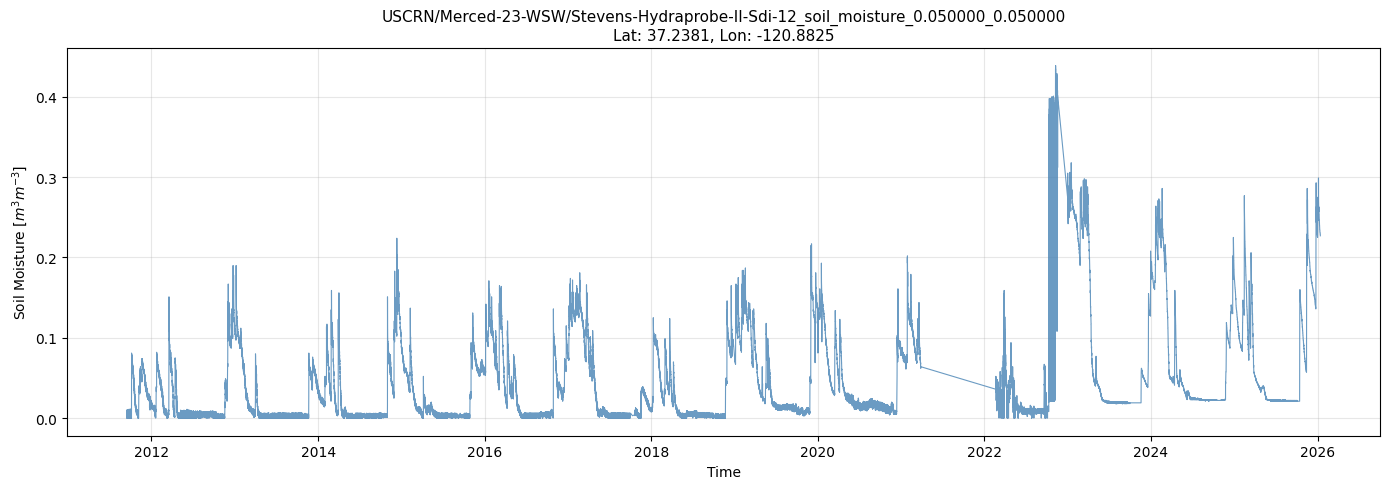

In [ ]:
# --- Usage ---
sensor_path = "USCRN/Merced-23-WSW/Stevens-Hydraprobe-II-Sdi-12_soil_moisture_0.050000_0.050000"
raw_ts = plot_sensor_timeseries(ismn_data, sensor_path)

In [ ]:
def plot_sensor_daily_avg(ismn_data, sensor_path):
    """
    Plot daily-averaged time series for a specific sensor.

    Parameters
    ----------
    ismn_data : ISMN_Interface
    sensor_path : str
        Format: "network/station/sensor_name"
    """
    parts = sensor_path.split("/")
    nw_name, st_name, sens_name = parts

    sensor = ismn_data[nw_name][st_name][sens_name]
    ts = sensor.data.copy()

    var_col = [c for c in ts.columns if "_flag" not in c and c != "date_time"]
    if not var_col:
        raise ValueError(f"No data column found for sensor: {sensor_path}")
    var_col = var_col[0]

    # Daily average
    daily = ts[[var_col]].resample("D").mean().dropna()

    meta = sensor.metadata.to_dict()
    lat = meta["latitude"][0][0]
    lon = meta["longitude"][0][0]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(daily.index, daily[var_col], linewidth=0.8, alpha=0.8, color="darkorange")
    ax.set_title(f"Daily Average — {sensor_path}\nLat: {lat}, Lon: {lon}", fontsize=11)
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{var_col.replace('_', ' ').title()} [$m^3 m^{{-3}}$]")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return daily


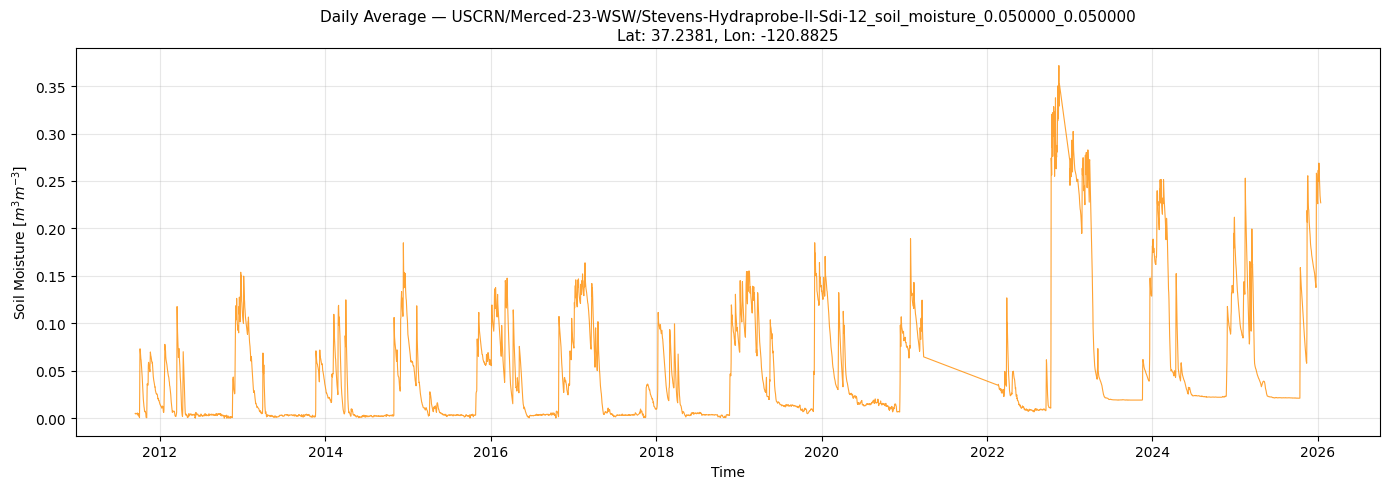

,soil_moisture
date_time,
2011-09-15,0.004727
2011-09-16,0.005125
2011-09-17,0.004500
2011-09-18,0.004583
2011-09-19,0.004583


In [ ]:
# --- Usage ---
sensor_path = "USCRN/Merced-23-WSW/Stevens-Hydraprobe-II-Sdi-12_soil_moisture_0.050000_0.050000"
daily_ts = plot_sensor_daily_avg(ismn_data, sensor_path)
daily_ts.head()

In [ ]:
import os

def export_all_sensor_csvs(ismn_data, output_dir="/content/sensor_csvs", variable="soil_moisture"):
    """
    For every sensor measuring `variable` across all networks/stations,
    save a CSV with daily-averaged data.

    CSV naming:  {network}_{station}_{instrument}_{lat}_{lon}.csv
        - instrument = first part of sensor name (before first '_')
        - lat/lon rounded to 5 decimal places

    CSV contents: two columns [date, swc]

    Parameters
    ----------
    ismn_data : ISMN_Interface
    output_dir : str
        Directory to save CSVs in. Created if it doesn't exist.
    variable : str
        Variable to filter sensors by (default: 'soil_moisture').
    """
    os.makedirs(output_dir, exist_ok=True)

    saved_files = []

    for network in ismn_data.networks:
        for station in ismn_data[network].stations:
            station_obj = ismn_data[network][station]

            for sensor in station_obj.iter_sensors(variable=variable):
                ts = sensor.data.copy()

                # Find the variable column
                var_col = [c for c in ts.columns if "_flag" not in c and c != "date_time"]
                if not var_col:
                    continue
                var_col = var_col[0]

                # Daily average
                daily = ts[[var_col]].resample("D").mean().dropna()
                if daily.empty:
                    continue

                # Rename to [date, swc]
                daily = daily.reset_index()
                daily.columns = ["date", "swc"]
                daily["date"] = daily["date"].dt.strftime("%Y%m%d")

                # Extract metadata for lat/lon
                meta = sensor.metadata.to_dict()
                lat = meta["latitude"][0][0]
                lon = meta["longitude"][0][0]

                # Extract instrument name (first part of sensor name before '_')
                # e.g. "CS655_soil_moisture_0.020000_0.020000" -> "CS655"
                instrument = sensor.name.split("_")[0]
                height = sensor.name.split("_")[-2]

                # Round lat/lon to 5 decimal places

                # Build filename
                fname = f"{network}_{station}_{instrument}_{height}_{lat}_{lon}.csv"
                # Sanitize filename (replace spaces/special chars)
                fname = fname.replace(" ", "-").replace("/", "-")

                fpath = os.path.join(output_dir, fname)
                daily.to_csv(fpath, index=False)
                saved_files.append(fpath)

                print(f"  Saved: {fname}  ({len(daily)} days)")

    print(f"\n{'='*60}")
    print(f"Total CSVs exported: {len(saved_files)}")
    print(f"Output directory: {output_dir}")
    return saved_files

# --- Run export ---
saved = export_all_sensor_csvs(ismn_data, output_dir="/content/ismn")

  Saved: FLUXNET-AMERIFLUX_BouldinIslandAlfalfa_CS655_0.020000_38.09915_-121.49933.csv  (1232 days)
  Saved: FLUXNET-AMERIFLUX_BouldinIslandAlfalfa_ThetaProbe-ML3_0.200000_38.09915_-121.49933.csv  (1232 days)
  Saved: FLUXNET-AMERIFLUX_BouldinIslandcorn_CS655_0.020000_38.10902_-121.53502.csv  (1128 days)
  Saved: FLUXNET-AMERIFLUX_BouldinIslandcorn_ThetaProbe-ML3_0.200000_38.10902_-121.53502.csv  (1123 days)
  Saved: FLUXNET-AMERIFLUX_ShermanBarn_ThetaProbe-ML2X_0.050000_38.04_-121.72715.csv  (720 days)
  Saved: FLUXNET-AMERIFLUX_ShermanIsland_ThetaProbe-ML2X_0.100000_38.0373_-121.7537.csv  (2535 days)
  Saved: FLUXNET-AMERIFLUX_ShermanIsland_ThetaProbe-ML2X_0.200000_38.0373_-121.7537.csv  (2679 days)
  Saved: FLUXNET-AMERIFLUX_TonziRanch_ThetaProbe-ML2X_0.200000_38.4316_-120.966.csv  (5778 days)
  Saved: FLUXNET-AMERIFLUX_TonziRanch_ThetaProbe-ML2X_0.000000_38.4316_-120.966.csv  (5784 days)
  Saved: FLUXNET-AMERIFLUX_TonziRanch_ThetaProbe-ML2X_0.500000_38.4316_-120.966.csv  (5782 days

In [ ]:
import os

def export_subroi_sensor_csvs(ismn_data, subroi_station_dict, output_dir="/content/sensor_csvs", variable="soil_moisture"):
    """
    For every sensor measuring `variable` at stations within the sub-ROIs,
    save a CSV with daily-averaged data.

    CSV naming:  {network}_{station}_{instrument}_{height}_{lat}_{lon}.csv
    CSV contents: two columns [date, swc]
    """
    os.makedirs(output_dir, exist_ok=True)

    saved_files = []

    for roi_id, roi_stations in subroi_station_dict.items():
        if len(roi_stations) == 0:
            print(f"Sub-ROI {roi_id}: No stations, skipping.")
            continue

        print(f"\n--- Sub-ROI {roi_id}: {len(roi_stations)} station(s) ---")

        roi_dir = os.path.join(output_dir, f"subroi_{roi_id}")
        os.makedirs(roi_dir, exist_ok=True)

        for _, st_row in roi_stations.iterrows():
            nw_name = st_row["network"]
            st_name = st_row["station"]

            try:
                station_obj = ismn_data[nw_name][st_name]
            except KeyError:
                print(f"  ⚠ Station not found: {nw_name}/{st_name}, skipping.")
                continue

            for sensor in station_obj.iter_sensors(variable=variable):
                ts = sensor.read_data()  # consistent with listing code

                sm_col = "soil_moisture"
                if sm_col not in ts.columns or ts[sm_col].dropna().empty:
                    continue

                # Daily average
                daily = ts[[sm_col]].resample("D").mean().dropna()
                if daily.empty:
                    continue

                # Rename to [date, swc]
                daily = daily.reset_index()
                daily.columns = ["date", "swc"]
                daily["date"] = daily["date"].dt.strftime("%Y-%m-%d")

                # Extract metadata for lat/lon
                meta = sensor.metadata.to_dict()
                lat = meta["latitude"][0][0]
                lon = meta["longitude"][0][0]

                # Extract instrument & height from sensor name
                # e.g. "CS655_soil_moisture_0.020000_0.020000" -> instrument="CS655", height="0.020000"
                instrument = sensor.name.split("_")[0]
                height = sensor.name.split("_")[-2]

                # BUG FIX: use nw_name and st_name, NOT network/station
                fname = f"{nw_name}_{st_name}_{instrument}_{height}_{lat}_{lon}.csv"
                fname = fname.replace(" ", "-").replace("/", "-")

                fpath = os.path.join(roi_dir, fname)
                daily.to_csv(fpath, index=False)
                saved_files.append(fpath)

                print(f"  Saved: subroi_{roi_id}/{fname}  ({len(daily)} days)")

    print(f"\n{'='*60}")
    print(f"Total CSVs exported: {len(saved_files)}")
    print(f"Output directory: {output_dir}")
    return saved_files


In [ ]:
saved = export_subroi_sensor_csvs(ismn_data, subroi_station_dict, output_dir="/content/ismn_sub")

Sub-ROI 0: No stations, skipping.

--- Sub-ROI 1: 6 station(s) ---
  Saved: subroi_1/FLUXNET-AMERIFLUX_BouldinIslandAlfalfa_CS655_0.020000_38.09915_-121.49933.csv  (1232 days)
  Saved: subroi_1/FLUXNET-AMERIFLUX_BouldinIslandAlfalfa_ThetaProbe-ML3_0.200000_38.09915_-121.49933.csv  (1232 days)
  Saved: subroi_1/FLUXNET-AMERIFLUX_BouldinIslandcorn_CS655_0.020000_38.10902_-121.53502.csv  (1128 days)
  Saved: subroi_1/FLUXNET-AMERIFLUX_BouldinIslandcorn_ThetaProbe-ML3_0.200000_38.10902_-121.53502.csv  (1123 days)
  Saved: subroi_1/FLUXNET-AMERIFLUX_ShermanBarn_ThetaProbe-ML2X_0.050000_38.04_-121.72715.csv  (720 days)
  Saved: subroi_1/FLUXNET-AMERIFLUX_ShermanIsland_ThetaProbe-ML2X_0.100000_38.0373_-121.7537.csv  (2535 days)
  Saved: subroi_1/FLUXNET-AMERIFLUX_ShermanIsland_ThetaProbe-ML2X_0.200000_38.0373_-121.7537.csv  (2679 days)
  Saved: subroi_1/FLUXNET-AMERIFLUX_TwitchellAlfalfa_ThetaProbe-ML2X_0.100000_38.1159_-121.6467.csv  (1733 days)
  Saved: subroi_1/FLUXNET-AMERIFLUX_TwitchellA

In [ ]:
import os
import zipfile
from google.colab import files

input_dir = '/content/ismn_sub'
output_zip = '/content/ismn_data_subroi.zip'

# Create a ZipFile object
with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files_in_dir in os.walk(input_dir):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            # Add file to zip, preserving directory structure relative to input_dir
            zf.write(file_path, os.path.relpath(file_path, input_dir))

print(f"Successfully created {output_zip}")

# Download the zip file
files.download(output_zip)

Successfully created /content/ismn_data_subroi.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
import os

folder_to_delete = '/content/ismn_sub'

if os.path.exists(folder_to_delete):
    shutil.rmtree(folder_to_delete)
    print(f"Folder '{folder_to_delete}' and its contents have been deleted.")
elif os.path.islink(folder_to_delete):
    os.unlink(folder_to_delete)
    print(f"Symlink '{folder_to_delete}' has been deleted.")
else:
    print(f"Folder '{folder_to_delete}' does not exist.")

Folder '/content/ismn_sub' and its contents have been deleted.
